# Investigating FBI NICS Background Checks
### Understanding system-wide background check demand with census context

<a id='intro'></a>
## Introduction

### Dataset Description
The FBI's National Instant Criminal Background Check System (NICS) publishes monthly counts of background checks for every U.S. state or territory along with detailed categories (permits, handguns, long guns, private sales, redemptions, etc.). The provided gun_data.csv file contains 12,485 monthly records spanning November 1998 through September 2017 across 55 jurisdictions and 27 numeric activity columns, culminating in the 	otals column. Key fields used in this investigation include permit, permit_recheck, handgun, long_gun, other, multiple, the private sale / return columns, and 	otals which summarizes each month's workload.

The companion us_census_data.csv table lists 85 "Fact" metrics for each state such as population, density, poverty, veteran counts, and median household income. Each fact occupies a row while the columns store the values for individual states. The file covers the 50 states (no District of Columbia or territories), so any merges will focus on those overlapping states.

### Project Approach
This project treats the NICS database as a large operational system whose load changes over time and varies by geography. Using NumPy, pandas, and visualization libraries inside this notebook lets me: (a) quantify national throughput, (b) analyze which states create the most per-capita demand and how that aligns with census demographics, and (c) identify where the system is accelerating. The findings are descriptive rather than causal, so any interpretations remain tentative until paired with policy or behavioral research.

### Research Questions
1. **Throughput** - How has the monthly throughput of the NICS background-check system evolved since 1999, and what long-run growth rate does that imply?
2. **Load distribution** - Which states generated the highest per-capita load in 2016, and how do demographics such as density, income, veteran presence, and poverty relate to those loads?
3. **Growth hotspots** - Which states show the steepest growth between 2010 and 2016, and do those surges overlap with today's per-capita hotspots?

These sequential questions help me reason about the NICS platform in a systems-oriented way: overall demand, spatial distribution, then dynamic growth.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk', palette='deep')
DATA_PATH = Path('data')
pd.set_option('display.max_columns', 30)

<a id='wrangling'></a>
## Data Wrangling

I first profiled both CSV files to understand their structure, time span, and data quality before creating analysis-ready tables.

### General Properties
The following checks inspect the row counts, date range, sample values, and missing-value patterns for both the FBI gun-check file and the census fact table.

In [2]:
# Load raw data
gun_checks = pd.read_csv(DATA_PATH / 'gun_data.csv')
census_raw = pd.read_csv(DATA_PATH / 'us_census_data.csv')

print(f"Gun check records: {gun_checks.shape[0]:,} rows x {gun_checks.shape[1]} columns")
print(f"Unique jurisdictions: {gun_checks['state'].nunique()}")
print(f"Date range (string format): {gun_checks['month'].min()} to {gun_checks['month'].max()}")

print('\nSample gun-check rows:')
display(gun_checks.head())

print('\nSelected numeric summary (permit + firearm specific columns):')
display(gun_checks[['permit', 'permit_recheck', 'handgun', 'long_gun', 'totals']].describe().T)

print('\nTop 5 columns by missing values (gun data):')
print(gun_checks.isna().sum().sort_values(ascending=False).head())

print('\nCensus table shape:', census_raw.shape)
print('Unique census fact rows:', census_raw['Fact'].nunique())
print('Example fact labels:', census_raw['Fact'].head(8).tolist())
display(census_raw.head())

Gun check records: 12,485 rows x 27 columns
Unique jurisdictions: 55
Date range (string format): 1998-11 to 2017-09

Sample gun-check rows:


,month,state,permit,permit_recheck,handgun,long_gun,other,multiple,admin,prepawn_handgun,prepawn_long_gun,prepawn_other,redemption_handgun,redemption_long_gun,redemption_other,returned_handgun,returned_long_gun,returned_other,rentals_handgun,rentals_long_gun,private_sale_handgun,private_sale_long_gun,private_sale_other,return_to_seller_handgun,return_to_seller_long_gun,return_to_seller_other,totals
0,2017-09,Alabama,16717.0,0.0,5734.0,6320.0,221.0,317,0.0,15.0,21.0,2.0,1378.0,1262.0,1.0,0.0,0.0,0.0,0.0,0.0,9.0,16.0,3.0,0.0,0.0,3.0,32019
1,2017-09,Alaska,209.0,2.0,2320.0,2930.0,219.0,160,0.0,5.0,2.0,0.0,200.0,154.0,2.0,28.0,30.0,0.0,0.0,0.0,17.0,24.0,1.0,0.0,0.0,0.0,6303
2,2017-09,Arizona,5069.0,382.0,11063.0,7946.0,920.0,631,0.0,13.0,6.0,0.0,1474.0,748.0,3.0,82.0,5.0,0.0,0.0,0.0,38.0,12.0,2.0,0.0,0.0,0.0,28394
3,2017-09,Arkansas,2935.0,632.0,4347.0,6063.0,165.0,366,51.0,12.0,13.0,0.0,1296.0,1824.0,4.0,0.0,0.0,0.0,0.0,0.0,13.0,23.0,0.0,0.0,2.0,1.0,17747
4,2017-09,California,57839.0,0.0,37165.0,24581.0,2984.0,0,0.0,0.0,0.0,0.0,535.0,397.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,123506



Selected numeric summary (permit + firearm specific columns):


,count,mean,std,min,25%,50%,75%,max
permit,12461.0,6413.629404,23752.338269,0.0,0.00,518.0,4272.00,522188.0
permit_recheck,1100.0,1165.956364,9224.200609,0.0,0.00,0.0,0.00,116681.0
handgun,12465.0,5940.881107,8618.584060,0.0,865.00,3059.0,7280.00,107224.0
long_gun,12466.0,7810.847585,9309.846140,0.0,2078.25,5122.0,10380.75,108058.0
totals,12485.0,21595.725911,32591.418387,0.0,4638.00,12399.0,25453.00,541978.0



Top 5 columns by missing values (gun data):
rentals_long_gun     11660
rentals_handgun      11495
permit_recheck       11385
returned_other       10670
returned_long_gun    10340
dtype: int64

Census table shape: (85, 52)
Unique census fact rows: 80
Example fact labels: ['Population estimates, July 1, 2016,  (V2016)', 'Population estimates base, April 1, 2010,  (V2016)', 'Population, percent change - April 1, 2010 (estimates base) to July 1, 2016,  (V2016)', 'Population, Census, April 1, 2010', 'Persons under 5 years, percent, July 1, 2016,  (V2016)', 'Persons under 5 years, percent, April 1, 2010', 'Persons under 18 years, percent, July 1, 2016,  (V2016)', 'Persons under 18 years, percent, April 1, 2010']


,Fact,Fact Note,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,Florida,Georgia,Hawaii,Idaho,Illinois,...,Oklahoma,Oregon,Pennsylvania,Rhode Island,South Carolina,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming
0,"Population estimates, July 1, 2016, (V2016)",NaN,"4,863,300","741,894","6,931,071","2,988,248","39,250,017","5,540,545","3,576,452","952,065","20,612,439","10,310,371","1,428,557","1,683,140","12,801,539",...,3923561,4093465,12784227,1056426,4961119,865454,6651194,"27,862,596","3,051,217","624,594","8,411,808","7,288,000","1,831,102","5,778,708","585,501"
1,"Population estimates base, April 1, 2010, (V2...",NaN,"4,780,131","710,249","6,392,301","2,916,025","37,254,522","5,029,324","3,574,114","897,936","18,804,592","9,688,680","1,360,301","1,567,650","12,831,574",...,3751615,3831072,12702857,1052940,4625410,814195,6346298,"25,146,100","2,763,888","625,741","8,001,041","6,724,545","1,853,011","5,687,289","563,767"
2,"Population, percent change - April 1, 2010 (es...",NaN,1.70%,4.50%,8.40%,2.50%,5.40%,10.20%,0.10%,6.00%,9.60%,6.40%,5.00%,7.40%,-0.20%,...,0.046,0.068,0.006,0.003,0.073,0.063,0.048,10.80%,10.40%,-0.20%,5.10%,8.40%,-1.20%,1.60%,3.90%
3,"Population, Census, April 1, 2010",NaN,"4,779,736","710,231","6,392,017","2,915,918","37,253,956","5,029,196","3,574,097","897,934","18,801,310","9,687,653","1,360,301","1,567,582","12,830,632",...,3751351,3831074,12702379,1052567,4625364,814180,6346105,"25,145,561","2,763,885","625,741","8,001,024","6,724,540","1,852,994","5,686,986","563,626"
4,"Persons under 5 years, percent, July 1, 2016, ...",NaN,6.00%,7.30%,6.30%,6.40%,6.30%,6.10%,5.20%,5.80%,5.50%,6.40%,6.40%,6.80%,6.00%,...,0.068,0.058,0.056,0.052,0.059,0.071,0.061,7.20%,8.30%,4.90%,6.10%,6.20%,5.50%,5.80%,6.50%


The quick scan confirms that the gun-check file is already tidy (one row per state-month) and covers 55 jurisdictions with data starting in late 1998. Most missing values occur in rarely used categories such as firearm rentals or permit rechecks, while 	otals, handgun, and long_gun are nearly complete. The census file stores 85 different facts per state in a wide format, and roughly 20 of those facts are legitimately blank for certain states (usually when the value is not collected).

### Data Cleaning
To prepare the files for analysis I:
- Converted the month column to pandas datetimes, added a year helper, and ensured all numeric gun-check columns are numeric with empty values treated as zero (rarely-reported categories only appear when activity exists).
- Filtered gun-check rows down to the 50 U.S. states that also exist in the census file so that per-capita calculations are valid.
- Wrote a small helper function to pull specific census facts multiple times, then assembled a tidy census_features table with population, density, veterans, income, and poverty metrics along with derived per-capita stats.
- Built reusable aggregates such as yearly totals per state for the later exploratory questions.

In [3]:
# Standardize gun-check data types and helper columns
gun_checks = gun_checks.sort_values('month').copy()
gun_checks['month'] = pd.to_datetime(gun_checks['month'])
numeric_cols = [col for col in gun_checks.columns if col not in {'month', 'state'}]
gun_checks[numeric_cols] = (
    gun_checks[numeric_cols]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
)
gun_checks['year'] = gun_checks['month'].dt.year

# Helper to extract tidy census metrics repeatedly
state_columns = [col for col in census_raw.columns if col not in {'Fact', 'Fact Note'}]

def extract_fact(label: str) -> pd.Series:
    '''Return a numeric Series indexed by state for the requested census label.'''
    row = census_raw.loc[census_raw['Fact'] == label, state_columns]
    if row.empty:
        raise ValueError(f'Missing census fact: {label}')
    series = row.iloc[0].astype(str)
    cleaned = (
        series.str.replace(',', '', regex=False)
              .str.replace('%', '', regex=False)
              .str.replace('$', '', regex=False)
              .str.replace('\u2212', '-', regex=False)
              .str.strip()
    )
    cleaned = cleaned.replace({'(NA)': np.nan, 'NA': np.nan, '': np.nan})
    return pd.to_numeric(cleaned, errors='coerce')

census_features = pd.DataFrame({'state': state_columns})
fact_map = {
    'Population estimates, July 1, 2016,  (V2016)': 'population_2016',
    'Population, Census, April 1, 2010': 'population_2010',
    'Population per square mile, 2010': 'population_density',
    'Median household income (in 2015 dollars), 2011-2015': 'median_household_income',
    'Veterans, 2011-2015': 'veterans',
    'Persons in poverty, percent': 'persons_in_poverty_pct',
}
for fact_label, new_col in fact_map.items():
    census_features[new_col] = census_features['state'].map(extract_fact(fact_label))

census_features['population_change_pct'] = (
    (census_features['population_2016'] - census_features['population_2010'])
    / census_features['population_2010'] * 100
)
census_features['veterans_per_1k'] = (
    census_features['veterans'] / census_features['population_2016'] * 1000
)

# Align gun-check rows with states that have census data
gun_states = gun_checks[gun_checks['state'].isin(census_features['state'])].copy()
state_year_totals = (
    gun_states.groupby(['state', 'year'])['totals']
    .sum()
    .reset_index()
)

print(f"Cleaned gun-check rows (50 states only): {gun_states.shape[0]:,}")
print(f"Years covered: {gun_states['year'].min()}-{gun_states['year'].max()}")
display(census_features.head())

Cleaned gun-check rows (50 states only): 11,350
Years covered: 1998-2017


,state,population_2016,population_2010,population_density,median_household_income,veterans,persons_in_poverty_pct,population_change_pct,veterans_per_1k
0,Alabama,4863300,4779736,94.4,43623,363170,17.1,1.748297,74.675632
1,Alaska,741894,710231,1.2,72515,69323,9.9,4.458127,93.440572
2,Arizona,6931071,6392017,56.3,50255,505794,16.4,8.433238,72.974869
3,Arkansas,2988248,2915918,56.0,41371,220953,17.2,2.480522,73.940650
4,California,39250017,37253956,239.1,61818,1777410,14.3,5.357984,45.284312


These steps create a consistent foundation: the gun-check file now uses numeric columns (zeros represent months with no activity in a given category), every row has explicit year/month helpers, and there is a 50-state subset ready for per-capita work. The custom extract_fact function let me pull population, density, income, veteran, and poverty metrics into one tidy census_features table, along with derived measures such as population change and veterans per 1,000 residents.

<a id='eda'></a>
## Exploratory Data Analysis

With clean tables in place I combined single-variable summaries (totals, per-capita rates, growth) and multi-variable views (per-capita load vs. census features) to answer the research questions below. Visualizations use Matplotlib/Seaborn for clarity and every plot is accompanied by text interpretation.

### RQ1 - How quickly has national NICS throughput grown over time?
I aggregated the monthly totals across all jurisdictions to quantify the overall load on the background-check system, then computed a 12-month rolling average and long-run compound annual growth rate (CAGR).

In [ ]:
monthly_totals = gun_checks.groupby('month')['totals'].sum().sort_index()
rolling_12 = monthly_totals.rolling(12).mean()
annual_totals = monthly_totals.resample('YE').sum()
complete_years = annual_totals[(annual_totals.index.year >= 1999) & (annual_totals.index.year <= 2016)]
cagr = (
    complete_years.iloc[-1] / complete_years.iloc[0]
) ** (1 / (complete_years.index.year[-1] - complete_years.index.year[0])) - 1
peak_month = monthly_totals.idxmax()
peak_value = monthly_totals.max()

recent_years = annual_totals.loc['2012-12-31':'2016-12-31'].rename('total_checks').to_frame()
recent_years.index = recent_years.index.year
display(recent_years)
print(f"Peak monthly workload: {peak_month.strftime('%b %Y')} with {peak_value:,.0f} checks")
print(f"1999->2016 CAGR: {cagr * 100:.1f}% per year")
print(f"Average monthly checks in 2016: {monthly_totals[monthly_totals.index.year == 2016].mean():,.0f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_totals.index, monthly_totals / 1e6, label='Monthly checks')
ax.plot(rolling_12.index, rolling_12 / 1e6, label='12-month rolling mean', linewidth=3)
ax.set(
    title='National NICS background checks over time',
    xlabel='Year',
    ylabel='Checks (millions)'
)
ax.legend()
ax.axvline(peak_month, color='gray', linestyle='--', alpha=0.5)
plt.show()

Monthly throughput roughly quadrupled over the life of the system. The 12-month average climbed from about 0.6 million checks in the early years to more than 2.2 million in 2016, and December 2015 set the single-month record at 3.3 million requests. The compound growth rate from 1999 to 2016 is roughly 6.7% per year, and the recent-year table shows acceleration (27.4 million checks processed in 2016 compared with 19.5 million in 2012). That continual rise means the NICS infrastructure had to scale throughput and staffing, not just absorb one-off surges.

### RQ2 - Which states create the heaviest per-capita load, and what characteristics align with that load?
To focus on a single recent year, I summed each state's 2016 totals, converted them to checks per 1,000 residents, and compared the top states against demographic metrics (density, income, veterans, poverty).

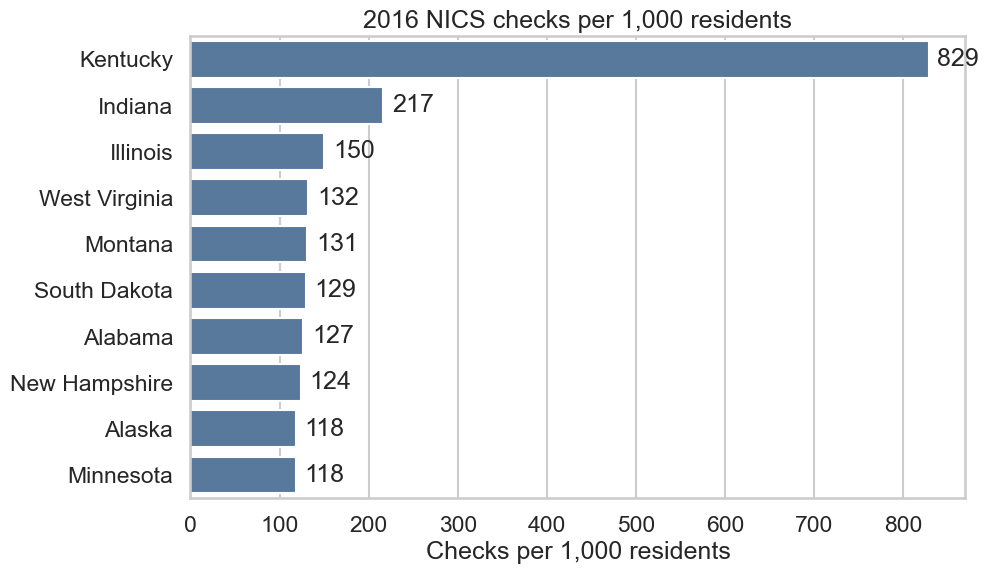

Correlation with per-capita load:
population_density        -0.202
median_household_income   -0.264
veterans_per_1k            0.070
persons_in_poverty_pct     0.226
Name: checks_per_1k, dtype: float64


,state,checks_per_1k,Handgun share
0,Kentucky,828.683468,56.3%
1,Indiana,216.600862,61.1%
2,Illinois,150.299898,66.5%
3,West Virginia,132.351993,53.2%
4,Montana,130.776388,39.8%
5,South Dakota,129.320565,42.4%
6,Alabama,126.857689,55.7%
7,New Hampshire,123.737353,60.5%
8,Alaska,118.139519,50.4%
9,Minnesota,118.044324,48.3%


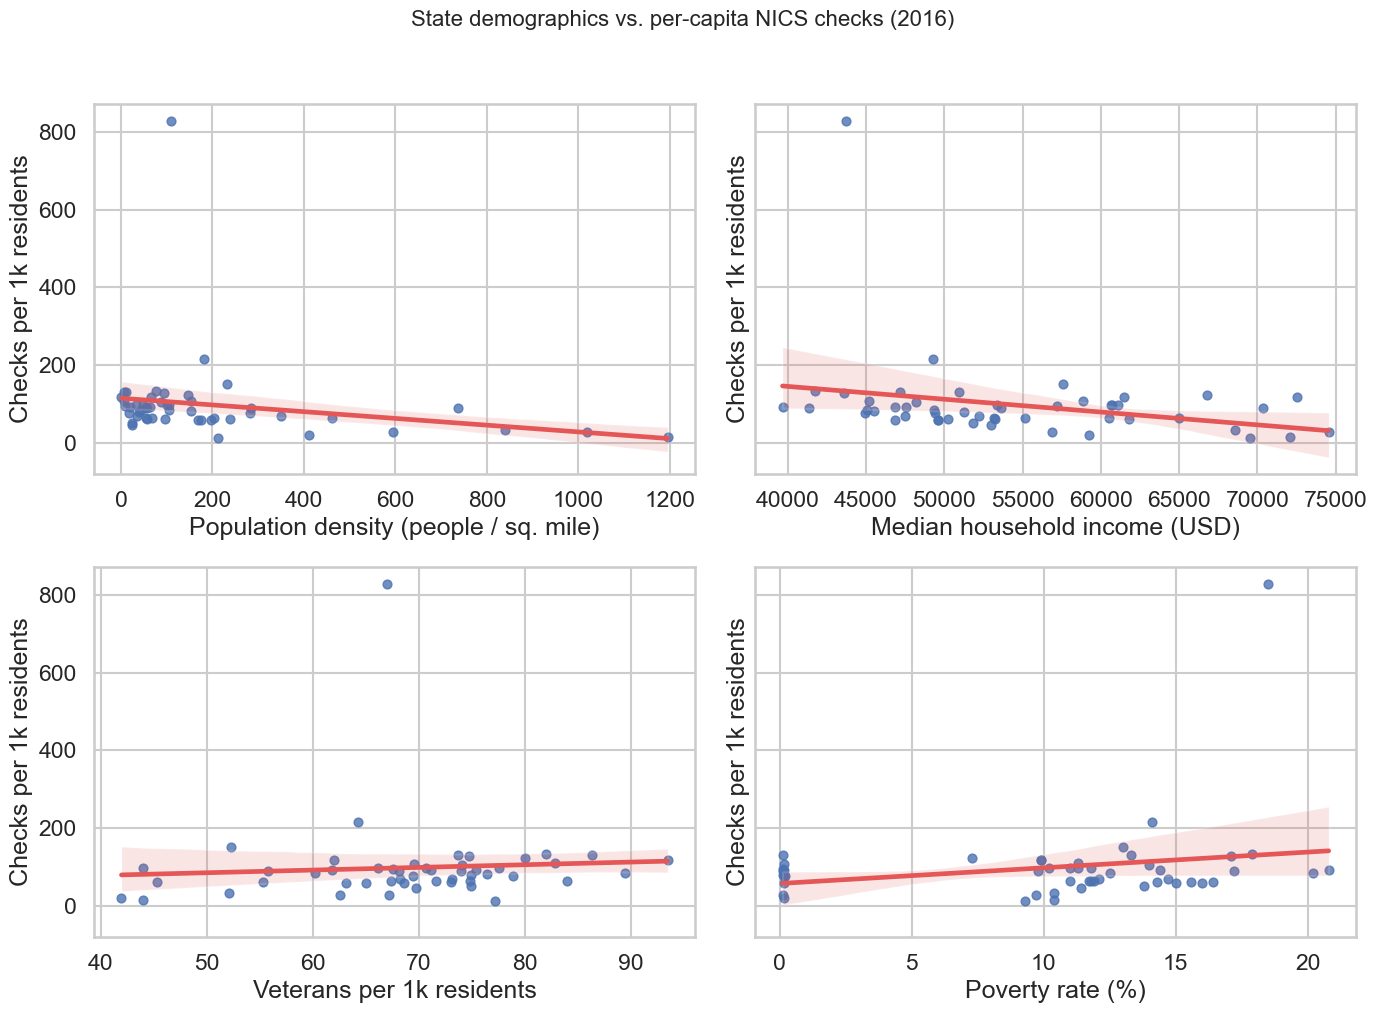

In [4]:
checks_2016 = gun_states[gun_states['year'] == 2016]
state_totals_2016 = (
    checks_2016.groupby('state')[['totals', 'handgun', 'long_gun', 'permit', 'permit_recheck']]
    .sum()
)
state_load = (
    state_totals_2016.join(census_features.set_index('state'), how='inner')
    .assign(
        checks_per_1k=lambda d: d['totals'] / d['population_2016'] * 1000,
        handgun_share=lambda d: d['handgun'] / (d['handgun'] + d['long_gun'])
    )
)
state_load['handgun_share'] = state_load['handgun_share'].fillna(0)

per_capita_top = state_load.sort_values('checks_per_1k', ascending=False).head(10).reset_index()
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=per_capita_top, x='checks_per_1k', y='state', color='#4C78A8', ax=ax)
ax.set(
    title='2016 NICS checks per 1,000 residents',
    xlabel='Checks per 1,000 residents',
    ylabel=''
)
for idx, value in enumerate(per_capita_top['checks_per_1k']):
    ax.text(value + 10, idx, f"{value:,.0f}", va='center')
plt.show()

feature_cols = [
    'population_density',
    'median_household_income',
    'veterans_per_1k',
    'persons_in_poverty_pct'
]
corr = state_load[['checks_per_1k'] + feature_cols].corr()['checks_per_1k'].drop('checks_per_1k')
print('Correlation with per-capita load:')
print(corr.round(3))

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
labels = [
    'Population density (people / sq. mile)',
    'Median household income (USD)',
    'Veterans per 1k residents',
    'Poverty rate (%)'
]
for ax, col, label in zip(axes.ravel(), feature_cols, labels):
    sns.regplot(
        data=state_load,
        x=col,
        y='checks_per_1k',
        scatter_kws={'s': 40, 'alpha': 0.8},
        line_kws={'color': '#E45756'},
        ax=ax
    )
    ax.set(xlabel=label, ylabel='Checks per 1k residents')
fig.suptitle('State demographics vs. per-capita NICS checks (2016)', fontsize=16, y=1.02)
fig.tight_layout()

per_capita_summary = per_capita_top[['state', 'checks_per_1k', 'handgun_share']].copy()
per_capita_summary['handgun_share'] = per_capita_summary['handgun_share'].map(lambda v: f"{v:.1%}")
per_capita_summary.rename(columns={'handgun_share': 'Handgun share'}, inplace=True)
display(per_capita_summary)

Kentucky is the overwhelming per-capita leader with roughly 829 checks per 1,000 residents, a direct result of the state's monthly concealed-carry permit rechecks that count as NICS transactions. Indiana (217 per 1k) and Illinois (150 per 1k) are the next heaviest loads, while the rest of the top 10 cluster between 118 and 133 checks per 1k (West Virginia, Montana, South Dakota, Alabama, New Hampshire, Alaska, Minnesota). Those states lean rural or have large permitting programs, and most top-ten states process a handgun share above 55% of their firearm transactions.

The scatter plots confirm only modest relationships: population density (-0.20) and median household income (-0.26) are negatively correlated with per-capita demand, implying sparser and lower-income states generate more checks. Poverty rate shows a weak positive correlation (+0.23) and veteran density is essentially flat (+0.07). Put differently, demographic context helps explain some variation, but state-level policies (permit rechecks, hunting culture) appear to dominate the per-capita workload.

### RQ3 - Where is demand accelerating since 2010, and does it overlap with the per-capita hotspots?
To capture momentum, I compared each state's annual totals in 2010 vs. 2016, highlighted the fastest growers, and flagged whether those states were already in the per-capita top ten identified above.

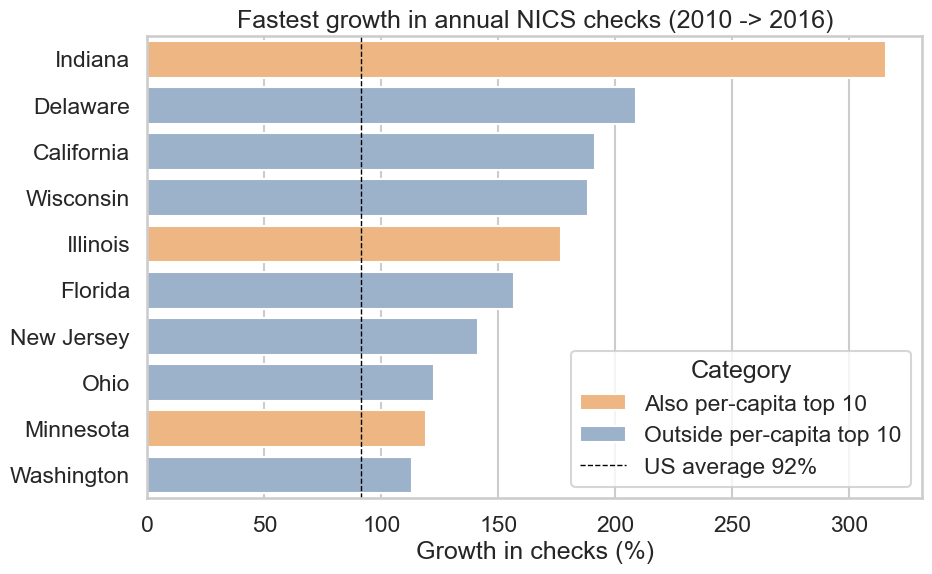

year,state,pct_change,abs_change,hotspot_label
0,Indiana,315.658904,1091075,Also per-capita top 10
1,Delaware,208.887734,40190,Outside per-capita top 10
2,California,191.177108,1560768,Outside per-capita top 10
3,Wisconsin,188.412553,367022,Outside per-capita top 10
4,Illinois,176.725155,1228770,Also per-capita top 10
5,Florida,156.609940,875993,Outside per-capita top 10
6,New Jersey,141.187997,71331,Outside per-capita top 10
7,Ohio,122.688875,482474,Outside per-capita top 10
8,Minnesota,119.105888,354209,Also per-capita top 10
9,Washington,112.915770,378654,Outside per-capita top 10


year,state,pct_change,abs_change
0,Utah,-46.684348,-258227
1,Alaska,32.981839,21738
2,Wyoming,33.295605,15885
3,Montana,34.860280,35242
4,Kansas,36.343961,52392


In [5]:
per_capita_hotspots = set(state_load.sort_values('checks_per_1k', ascending=False).head(10).index)
state_growth = (
    gun_states[gun_states['year'].isin([2010, 2016])]
    .groupby(['state', 'year'])['totals']
    .sum()
    .unstack()
    .dropna()
    .rename(columns={2010: 'checks_2010', 2016: 'checks_2016'})
)
state_growth['pct_change'] = (state_growth['checks_2016'] - state_growth['checks_2010']) / state_growth['checks_2010'] * 100
state_growth['abs_change'] = state_growth['checks_2016'] - state_growth['checks_2010']
state_growth['hotspot_label'] = np.where(
    state_growth.index.isin(per_capita_hotspots),
    'Also per-capita top 10',
    'Outside per-capita top 10'
)

top_growth = state_growth.sort_values('pct_change', ascending=False).head(10).reset_index()
declines = state_growth.sort_values('pct_change').head(5).reset_index()
annual_state_totals = gun_states.groupby('year')['totals'].sum()
national_growth = (annual_state_totals.loc[2016] / annual_state_totals.loc[2010] - 1) * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=top_growth,
    x='pct_change',
    y='state',
    hue='hotspot_label',
    palette=['#FFB570', '#94B1D2'],
    ax=ax
)
ax.axvline(national_growth, color='black', linestyle='--', linewidth=1, label=f'US average {national_growth:.0f}%')
ax.set(
    title='Fastest growth in annual NICS checks (2010 -> 2016)',
    xlabel='Growth in checks (%)',
    ylabel=''
)
ax.legend(loc='lower right', title='Category')
plt.show()

display(top_growth[['state', 'pct_change', 'abs_change', 'hotspot_label']])
display(declines[['state', 'pct_change', 'abs_change']])

System momentum is concentrated in a different set of states than the per-capita list. Indiana (+316%) is both a growth leader and a per-capita hotspot, but other large increases came from California (+191%), Wisconsin (+188%), Illinois (+177%), Florida (+157%), and Washington (+113%) - states with sizable populations whose absolute additions ranged from roughly 350k to 1.6M extra checks per year. Only three of the ten fastest growers overlap with the 2016 per-capita top tier (Indiana, Illinois, Minnesota), meaning new load centers are emerging outside the previously identified hotspots.

Nationally, 2016 demand was about 92% higher than 2010, and Utah was the lone state with a decline (-47%) after an earlier permitting surge. Alaska, Wyoming, Montana, and Kansas barely grew (30-36%), suggesting some regions have already plateaued. Knowing which jurisdictions are accelerating helps the FBI plan staffing and technology capacity beyond simply watching today's per-capita heavyweights.

<a id='conclusions'></a>
## Conclusions

- The NICS program has transformed into a high-throughput system: total checks grew from roughly 9 million in 1999 to 27.4 million in 2016, and the sustained 6-7% annual growth plus recurring spikes (for example December 2015) imply continual capacity planning rather than rare surges.
- Per-capita load is dominated by states with recurring permit checks (Kentucky, Indiana, Illinois) and rural hunting cultures (West Virginia, Montana, South Dakota). Demographics explain only a slice of the variance - policy choices and local firearms ecosystems are stronger drivers.
- Momentum since 2010 is strongest in industrial and coastal states (Indiana, California, Wisconsin, Florida, Washington) with large absolute increases, and only a minority of those overlap with the per-capita leaders. That tells system planners to watch both per-capita intensity and multi-year growth when allocating resources.

### Limitations and Next Steps
- A NICS background check is not a one-to-one proxy for firearm purchases (permit rechecks, private sales, and state-specific rules all influence counts), so interpretations remain descriptive.
- The census file omits the District of Columbia and territories, and the 2017 portion of the gun-check data is partial (through September), so analyses stopped at 2016 for year-level comparisons.
- Future work could layer in policy timelines or economic indicators to explain the spikes, track per-capita changes over time rather than a single year, or examine specific transaction types (handgun vs. permit) for capacity planning. Pairing those studies with qualitative research would help convert these descriptive signals into actionable insights.

In [6]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

[NbConvertApp] Converting notebook Investigate_a_Dataset.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 712876 bytes to Investigate_a_Dataset.html
